# Задача 2. Реализация подсчёта треугольников
## Настройка виртуального окружения
```bash
python -m venv .venv

source .venv/Scripts/activate

pip install -r req.txt
```

In [ ]:
# Импорт необходимых библиотек

import graphblas as gb
from graphblas import Matrix, dtypes
from graphblas.io import mmread

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import os
import time

In [2]:
# проверка на неориентированность
def isDisorientation(M):
    return M.isequal(M.T)

Используя `python-graphblas` реализовать наивный алгоритм, для матрицы смежности $A$ вычисляющий $A^3$ и возвращающий количество треугольников неориентированного графа.
- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
- Функция возвращает число --- количество треугольников в графе.

In [3]:
def naiveA3(A):
    A_new = A.dup()
    A_new.setdiag(0)
    return int(A_new.mxm(A_new.mxm(A_new)).diag().reduce(gb.agg.sum).value or 0) / 6

Используя `python-graphblas` реализовать наивный алгоритм с маской, для матрицы смежности $A$ вычисляющий $A^2$ и возвращающий количество треугольников неориентированного графа.
- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
- Функция возвращает число --- количество треугольников в графе.

In [4]:
def naiveA2mask(A):
    A_new = A.dup()
    A_new.setdiag(0)
    mask = A_new.dup(dtype = dtypes.BOOL)
    return int(A_new.mxm(A_new).dup(mask = mask).reduce_scalar(gb.monoid.plus).value or 0) / 6

Используя `python-graphblas` реализовать Сohen's algorithm, вычисляющий количество треугольников неориентированного графа.
- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
- Функция возвращает число --- количество треугольников в графе.

In [5]:
def cohen(A):
    A_new = A.dup()
    A_new.setdiag(0)
    mask = A_new.dup(dtype = dtypes.BOOL)
    return int(gb.select.tril(A_new).mxm(gb.select.triu(A_new)).dup(mask = mask).reduce_scalar(gb.monoid.plus).value or 0) / 2

(+2 балла) Используя `python-graphblas` реализовать функцию, вычисляющую для каждой вершины неориентированного графа количество треугольников, в которых она участвует.
- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
- Функция возвращает массив, где для каждой вершины указано, в скольких треугольниках она участвует.

In [6]:
def getTriangles(A):
    A_new = A.dup()
    A_new.setdiag(0)
    mask = A_new.dup(dtype = dtypes.BOOL)
    return A_new.mxm(A_new).dup(mask = mask).reduce_rowwise().to_dense(0) // 2

Добавить тесты для проверки корректности полученных реализаций.

In [7]:
def createTestGraphs():
    """Создаёт набор тестовых графов"""
    test_cases = []
    
    # 1. Пустой граф (3 вершины, нет рёбер)
    A_empty = Matrix(int, 3, 3)
    # Матрица уже пустая по умолчанию
    test_cases.append(("Пустой граф", A_empty, 0, [0,0,0]))
    
    # 2. Полный граф K3 (треугольник)
    K3 = Matrix(int, 3, 3)
    K3[0,1] = 1; K3[1,0] = 1
    K3[0,2] = 1; K3[2,0] = 1
    K3[1,2] = 1; K3[2,1] = 1
    test_cases.append(("K3 (треугольник)", K3, 1, [1,1,1]))
    
    # 3. Полный граф K4
    K4 = Matrix(int, 4, 4)
    edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
    for i, j in edges:
        K4[i,j] = 1
        K4[j,i] = 1
    test_cases.append(("K4", K4, 4, [3,3,3,3]))  # C(4,3) = 4 треугольника
    
    # 4. Граф-звезда (без треугольников)
    star = Matrix(int, 4, 4)
    center = 0
    for leaf in range(1, 4):
        star[center, leaf] = 1
        star[leaf, center] = 1
    test_cases.append(("Звезда", star, 0, [0,0,0,0]))
    
    # 5. Граф с двумя треугольниками
    two_triangles = Matrix(int, 6, 6)
    # Первый треугольник (0,1,2)
    tri1 = [(0,1), (1,2), (2,0)]
    # Второй треугольник (3,4,5)
    tri2 = [(3,4), (4,5), (5,3)]
    # Связь между треугольниками
    connection = [(1,3)]  # ребро между вершинами 1 и 3
    
    for i, j in tri1 + tri2 + connection:
        two_triangles[i,j] = 1
        two_triangles[j,i] = 1
    
    # Ожидаемое количество треугольников:
    # Каждая вершина в первом треугольнике: 1 треугольник
    # Каждая вершина во втором треугольнике: 1 треугольник
    # Вершина 1 (связующая) участвует в 1 треугольнике (первом)
    # Вершина 3 (связующая) участвует в 1 треугольнике (втором)
    expected_per_vertex = [1, 1, 1, 1, 1, 1]  # по одному треугольнику на вершину
    
    test_cases.append(("Два треугольника", two_triangles, 2, expected_per_vertex))
    
    # 6. Граф-клика с 5 вершинами (K5)
    K5 = Matrix(int, 5, 5)
    for i in range(5):
        for j in range(i+1, 5):
            K5[i,j] = 1
            K5[j,i] = 1
    # Количество треугольников в K5 = C(5,3) = 10
    # Каждая вершина участвует в C(4,2) = 6 треугольниках
    test_cases.append(("K5", K5, 10, [6,6,6,6,6]))
    
    # 7. Граф-колесо с 5 вершинами (W5)
    wheel = Matrix(int, 5, 5)
    # Центральная вершина 0 соединена со всеми
    for i in range(1, 5):
        wheel[0,i] = 1
        wheel[i,0] = 1
    
    # Внешний цикл: 1-2-3-4-1
    outer_cycle = [(1,2), (2,3), (3,4), (4,1)]
    for i, j in outer_cycle:
        wheel[i,j] = 1
        wheel[j,i] = 1
    
    # В колесе W5: 4 треугольника (каждый с центром)
    # Вершина 0: 4 треугольника
    # Вершины 1-4: по 2 треугольника (один с центром, один во внешнем цикле)
    expected_per_vertex_wheel = [4, 2, 2, 2, 2]
    test_cases.append(("Колесо W5", wheel, 4, expected_per_vertex_wheel))
    
    # 8. Граф с петлями (для проверки игнорирования петель)
    graph_with_loops = Matrix(int, 3, 3)
    graph_with_loops[0,0] = 1  # петля
    graph_with_loops[0,1] = 1; graph_with_loops[1,0] = 1
    graph_with_loops[0,2] = 1; graph_with_loops[2,0] = 1
    graph_with_loops[1,2] = 1; graph_with_loops[2,1] = 1
    
    # Должен считаться как K3 (1 треугольник), петли игнорируются
    test_cases.append(("Граф с петлями", graph_with_loops, 1, [1,1,1]))
    
    # 9. Граф-путь из 4 вершин (без треугольников)
    path = Matrix(int, 4, 4)
    path_edges = [(0,1), (1,2), (2,3)]
    for i, j in path_edges:
        path[i,j] = 1
        path[j,i] = 1
    test_cases.append(("Путь P4", path, 0, [0,0,0,0]))
    
    # 10. Граф-цикл из 4 вершин (C4) - нет треугольников
    cycle4 = Matrix(int, 4, 4)
    cycle_edges = [(0,1), (1,2), (2,3), (3,0)]
    for i, j in cycle_edges:
        cycle4[i,j] = 1
        cycle4[j,i] = 1
    test_cases.append(("Цикл C4", cycle4, 0, [0,0,0,0]))
    
    return test_cases


Тест 1: Пустой граф
Граф неориентированный: True


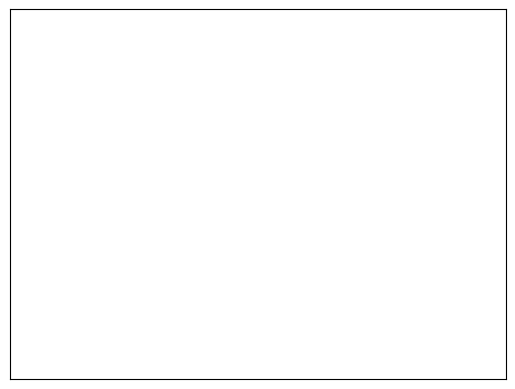

naiveA3: 0.0
naiveA2mask: 0.0
cohen: 0.0
per vertex: [0 0 0]

Тест 2: K3 (треугольник)
Граф неориентированный: True


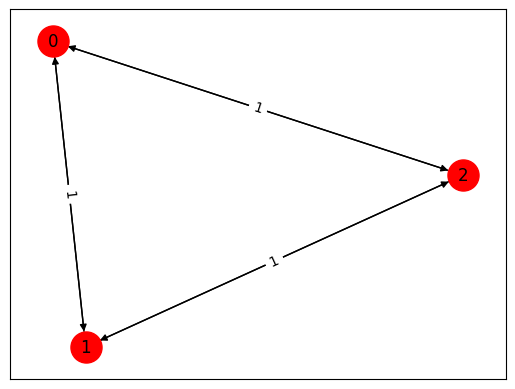

naiveA3: 1.0
naiveA2mask: 1.0
cohen: 1.0
per vertex: [1 1 1]

Тест 3: K4
Граф неориентированный: True


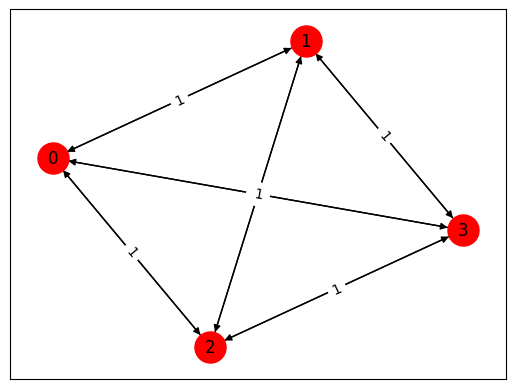

naiveA3: 4.0
naiveA2mask: 4.0
cohen: 4.0
per vertex: [3 3 3 3]

Тест 4: Звезда
Граф неориентированный: True


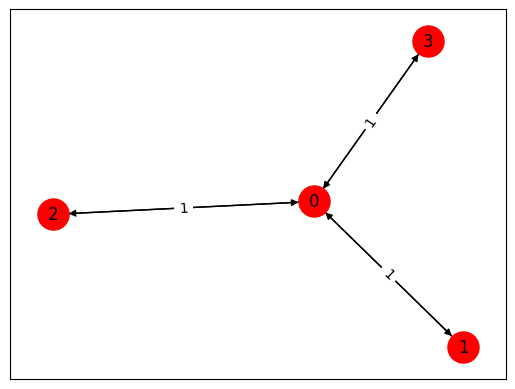

naiveA3: 0.0
naiveA2mask: 0.0
cohen: 0.0
per vertex: [0 0 0 0]

Тест 5: Два треугольника
Граф неориентированный: True


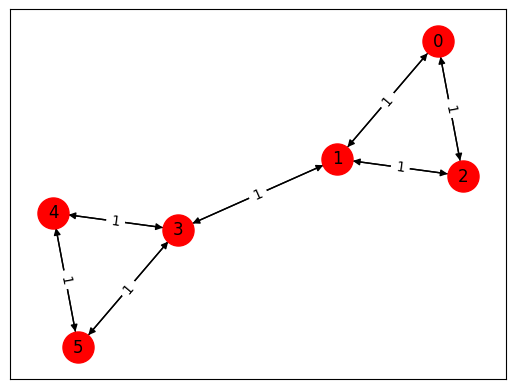

naiveA3: 2.0
naiveA2mask: 2.0
cohen: 2.0
per vertex: [1 1 1 1 1 1]

Тест 6: K5
Граф неориентированный: True


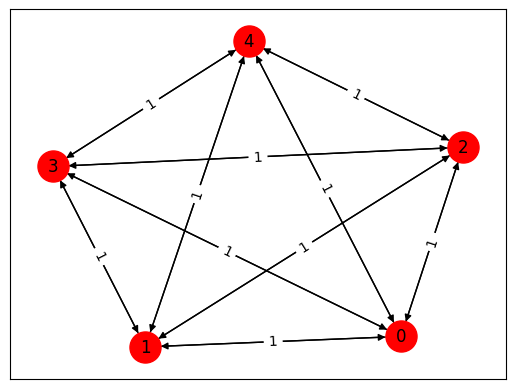

naiveA3: 10.0
naiveA2mask: 10.0
cohen: 10.0
per vertex: [6 6 6 6 6]

Тест 7: Колесо W5
Граф неориентированный: True


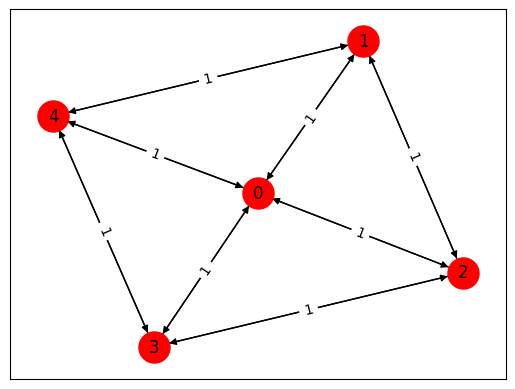

naiveA3: 4.0
naiveA2mask: 4.0
cohen: 4.0
per vertex: [4 2 2 2 2]

Тест 8: Граф с петлями
Граф неориентированный: True


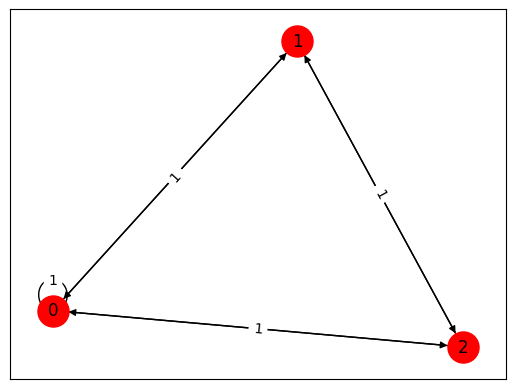

naiveA3: 1.0
naiveA2mask: 1.0
cohen: 1.0
per vertex: [1 1 1]

Тест 9: Путь P4
Граф неориентированный: True


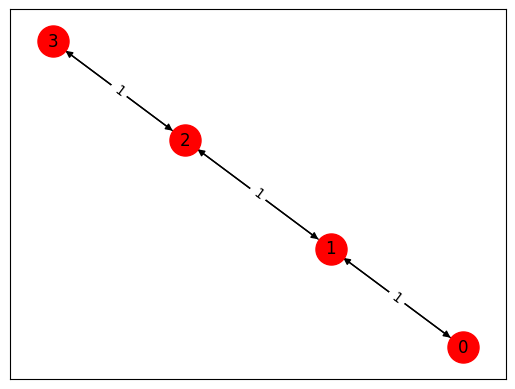

naiveA3: 0.0
naiveA2mask: 0.0
cohen: 0.0
per vertex: [0 0 0 0]

Тест 10: Цикл C4
Граф неориентированный: True


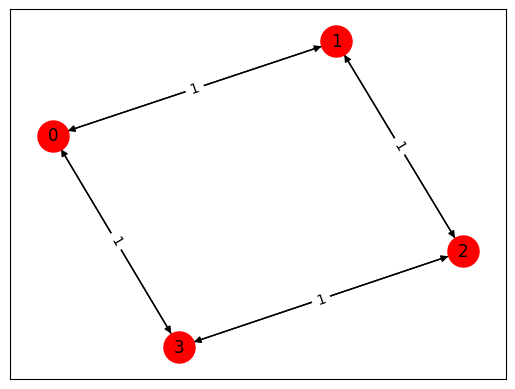

naiveA3: 0.0
naiveA2mask: 0.0
cohen: 0.0
per vertex: [0 0 0 0]


In [ ]:
def testAlgorithms():
    """Тестирует все алгоритмы на всех тестовых графах"""
    test_cases = createTestGraphs()
    
    i = 0
    for name, A, expected_total, expected_per_vertex in test_cases:
        i += 1
        print(f"\nТест {i}: {name}")
        
        # Проверяем, что граф неориентированный
        is_undirected = isDisorientation(A)
        print(f"Граф неориентированный: {is_undirected}")
        
        if is_undirected:
            
            gb.viz.draw(A)
            naive_result = naiveA3(A)
            naive_mask_result = naiveA2mask(A)
            cohen_result = cohen(A)
            per_vertex_result = getTriangles(A)
            
            assert naive_result == expected_total, \
                f"{name}: naiveA3 = {naive_result}, ожидалось {expected_total}"
            assert naive_mask_result == expected_total, \
                f"{name}: naiveA2mask = {naive_mask_result}, ожидалось {expected_total}"
            assert cohen_result == expected_total, \
                f"{name}: cohen = {cohen_result}, ожидалось {expected_total}"
            
            assert np.array_equal(per_vertex_result, expected_per_vertex), \
                f"{name}: getTriangles = {per_vertex_result}, ожидалось {expected_per_vertex}"
            
            print(f"naiveA3: {naive_result}")
            print(f"naiveA2mask: {naive_mask_result}")
            print(f"cohen: {cohen_result}")
            print(f"per vertex: {per_vertex_result}")
            
testAlgorithms()

(+1 балл) Скачать 10 графов в формате `Matrix Market` с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/) и оценить время работы всех полученных реализаций. Сделать выводы.
- В качестве фильтров для поиска графов на сайте использовать следующие значения: `Rutherford-Boeing Type` = `Binary`, `Special Structure` = `Symmetric`, `Nonzeros.Min` = 10000.

In [9]:
def testTime(A, iters):
    
	result = [naiveA3(A), naiveA2mask(A), cohen(A)]
	print(f'Размер матрицы: {A.shape[0]}x{A.shape[1]}, результаты: {result}, разреженность: {100 - A.nvals * 100 / (A.shape[0] * A.shape[1]):.4f}%')
	if not all(element == element for element in result):
		print("Не все результаты совпадают!")
	else:
		results = {}

		total_time = 0
		for _ in range(iters):
			start = time.perf_counter()
			naiveA3(A)
			total_time += time.perf_counter() - start
		results['naiveA3'] = total_time / iters
		
		total_time = 0
		for _ in range(iters):
			start = time.perf_counter()
			naiveA2mask(A)
			total_time += time.perf_counter() - start
		results['naiveA2mask'] = total_time / iters

		total_time = 0
		for _ in range(iters):
			start = time.perf_counter()
			cohen(A)
			total_time += time.perf_counter() - start
		results['cohen'] = total_time / iters

		return results

In [10]:
files = os.listdir('./data')

iters = 10
results = {}

for i in range(len(files)):
	
	A = mmread(f'./data/{files[i]}')
	results[A.shape[0]] = testTime(A, iters)

results = dict(sorted(results.items()))

Размер матрицы: 1024x1024, результаты: [2047.0, 2047.0, 2047.0], разреженность: 99.4171%
Размер матрицы: 2048x2048, результаты: [4104.0, 4104.0, 4104.0], разреженность: 99.7078%
Размер матрицы: 4096x4096, результаты: [8215.0, 8215.0, 8215.0], разреженность: 99.8538%
Размер матрицы: 8192x8192, результаты: [16442.0, 16442.0, 16442.0], разреженность: 99.9268%
Размер матрицы: 16384x16384, результаты: [32921.0, 32921.0, 32921.0], разреженность: 99.9634%
Размер матрицы: 32768x32768, результаты: [65872.0, 65872.0, 65872.0], разреженность: 99.9817%
Размер матрицы: 65536x65536, результаты: [131842.0, 131842.0, 131842.0], разреженность: 99.9908%
Размер матрицы: 131072x131072, результаты: [263620.0, 263620.0, 263620.0], разреженность: 99.9954%
Размер матрицы: 262144x262144, результаты: [527234.0, 527234.0, 527234.0], разреженность: 99.9977%
Размер матрицы: 524288x524288, результаты: [1054626.0, 1054626.0, 1054626.0], разреженность: 99.9989%


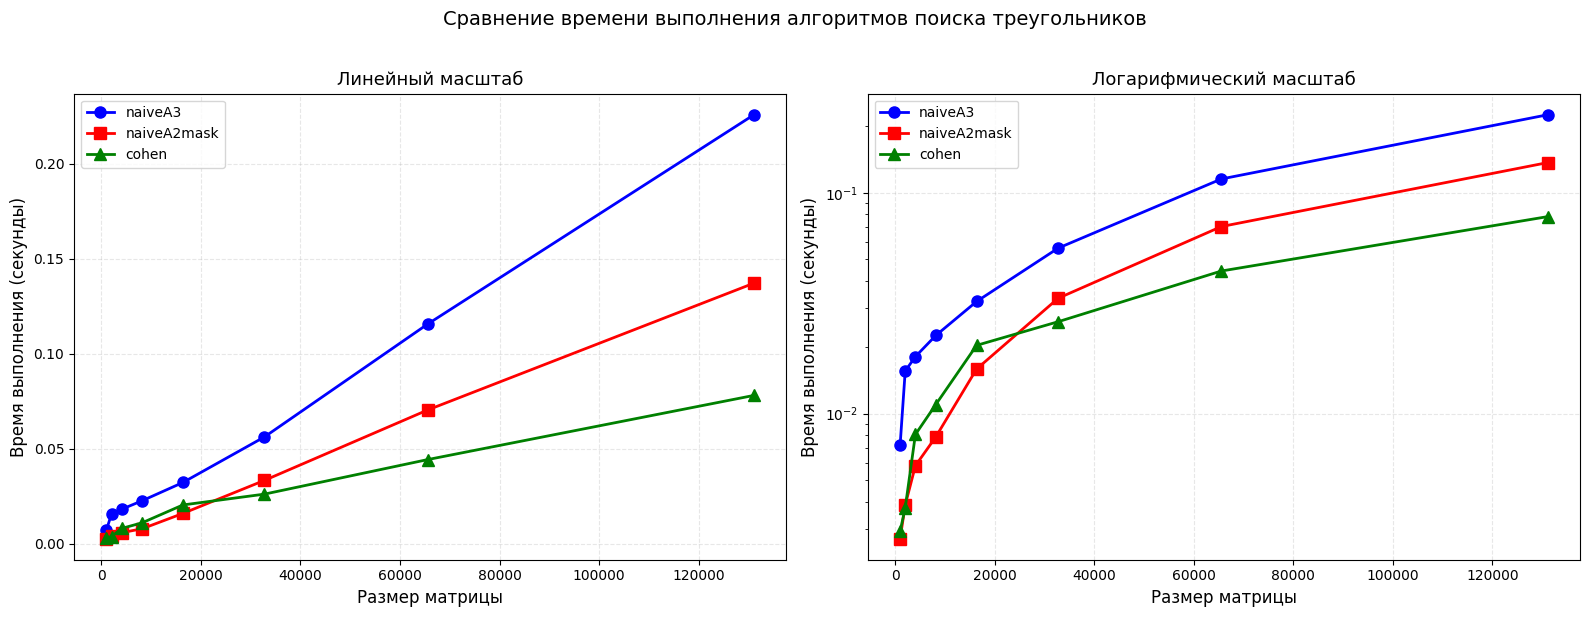

In [11]:
sizes = [item[0] for item in results.items()]
naive_times = [item[1]['naiveA3'] for item in results.items()]
mask_times = [item[1]['naiveA2mask'] for item in results.items()]
cohen_times = [item[1]['cohen'] for item in results.items()]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

def setup_plot(ax, title, yscale='linear'):
    ax.plot(sizes[:8], naive_times[:8], marker = 'o', color = 'blue', linewidth = 2, markersize = 8, label = 'naiveA3')
    ax.plot(sizes[:8], mask_times[:8], marker = 's', color = 'red', linewidth = 2, markersize = 8, label = 'naiveA2mask')
    ax.plot(sizes[:8], cohen_times[:8], marker = '^', color = 'green', linewidth = 2, markersize = 8, label = 'cohen')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlabel('Размер матрицы', fontsize = 12)
    ax.set_ylabel('Время выполнения (секунды)', fontsize = 12)
    ax.set_title(title, fontsize = 13)
    ax.legend(loc='upper left')
    ax.set_yscale(yscale)
    
    if yscale == 'linear':
        for _, (x, y) in enumerate(zip(sizes[:4], naive_times[:4])):
            if y > 0.1:
                ax.annotate(f'{y:.2f}s', (x, y), textcoords = "offset points", 
                           xytext = (0,10), ha='center', fontsize = 8)

setup_plot(ax1, 'Линейный масштаб', 'linear')
setup_plot(ax2, 'Логарифмический масштаб', 'log')

plt.suptitle('Сравнение времени выполнения алгоритмов поиска треугольников', 
             fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

## Выводы 
- Все алгоритмы показали сложность ```O(n)```, что говорит о том, что графы были экстремально разреженными (средняя степень постоянна)
- Алгоритм Кохена и умножение с маской показывают сравнительно одинаковые результаты
- Наивный алгоритм не подходит для умножения больших матриц

(+2 балла) Реализовать генератор случайных неориентированных графов, в котором можно задавать количество вершин и степень разреженности графа. Путём генерации случайных графов различного размера и с разной степенью разреженности, оценить время работы всех полученных реализаций и исследовать границы их применимости. Сделать выводы.

В качестве алгоритма для генерации случайных графов была выбрана модель Watts–Strogatz, которая обладает свойствами "малого мира", включая короткую среднюю длину пути и высокую кластеризацию

In [ ]:
def WattsStrogatz(n, sparcity, p = 0.1, seed = 42):
    """
    WS граф с контролем плотности через k
    
    Parameters:
    - n: количество вершин
    - target_sparcity: целевая разреженность
    - p: вероятность пересоединения (структура)
    """

    target_density = 1 - sparcity
    k = int(target_density * (n - 1))
    
    k = max(2, min(k, n - 1))
    if k % 2 != 0:
        k += 1

    G = nx.watts_strogatz_graph(n, k, p, seed=seed)
    
    A_coo = nx.to_scipy_sparse_array(G)
    A_dense = A_coo.toarray()
    A = gb.Matrix.from_dense(A_dense.astype(int))
    
    A = A.select('!=', 0)

    return A

In [13]:
sparsity_by_size = {
    1024: [0.99, 0.95, 0.9],
    2048: [0.99, 0.95, 0.9],
    4096: [0.99, 0.95, 0.9],
    8192: [0.99],
    16384: [0.99]
}

sizes = sparsity_by_size.keys()


results = {}
iters = 3

for size in sizes:
    results[size] = {}
    
    for sparcity in sparsity_by_size[size]:
        
        A = WattsStrogatz(size, sparcity)
        results[size][sparcity] = testTime(A, iters)

Размер матрицы: 1024x1024, результаты: [7403.0, 7403.0, 7403.0], разреженность: 99.0234%
Размер матрицы: 1024x1024, результаты: [243237.0, 243237.0, 243237.0], разреженность: 94.9219%
Размер матрицы: 1024x1024, результаты: [964843.0, 964843.0, 964843.0], разреженность: 90.0391%
Размер матрицы: 2048x2048, результаты: [66844.0, 66844.0, 66844.0], разреженность: 99.0234%
Размер матрицы: 2048x2048, результаты: [1912351.0, 1912351.0, 1912351.0], разреженность: 95.0195%
Размер матрицы: 2048x2048, результаты: [7825982.0, 7825982.0, 7825982.0], разреженность: 90.0391%
Размер матрицы: 4096x4096, результаты: [564240.0, 564240.0, 564240.0], разреженность: 99.0234%
Размер матрицы: 4096x4096, результаты: [15509287.0, 15509287.0, 15509287.0], разреженность: 95.0195%
Размер матрицы: 4096x4096, результаты: [63640372.0, 63640372.0, 63640372.0], разреженность: 89.9902%
Размер матрицы: 8192x8192, результаты: [4897118.0, 4897118.0, 4897118.0], разреженность: 98.9990%
Размер матрицы: 16384x16384, результат

In [14]:
rows = []
for size, sparsities in results.items():
    for sparsity, algorithms in sparsities.items():
        for algo, time in algorithms.items():
            rows.append({
                'size': size,
                'sparsity': sparsity,
                'algorithm': algo,
                'time': time
            })

df = pd.DataFrame(rows)

df = df.sort_values(['size', 'sparsity', 'algorithm']).reset_index(drop = True)

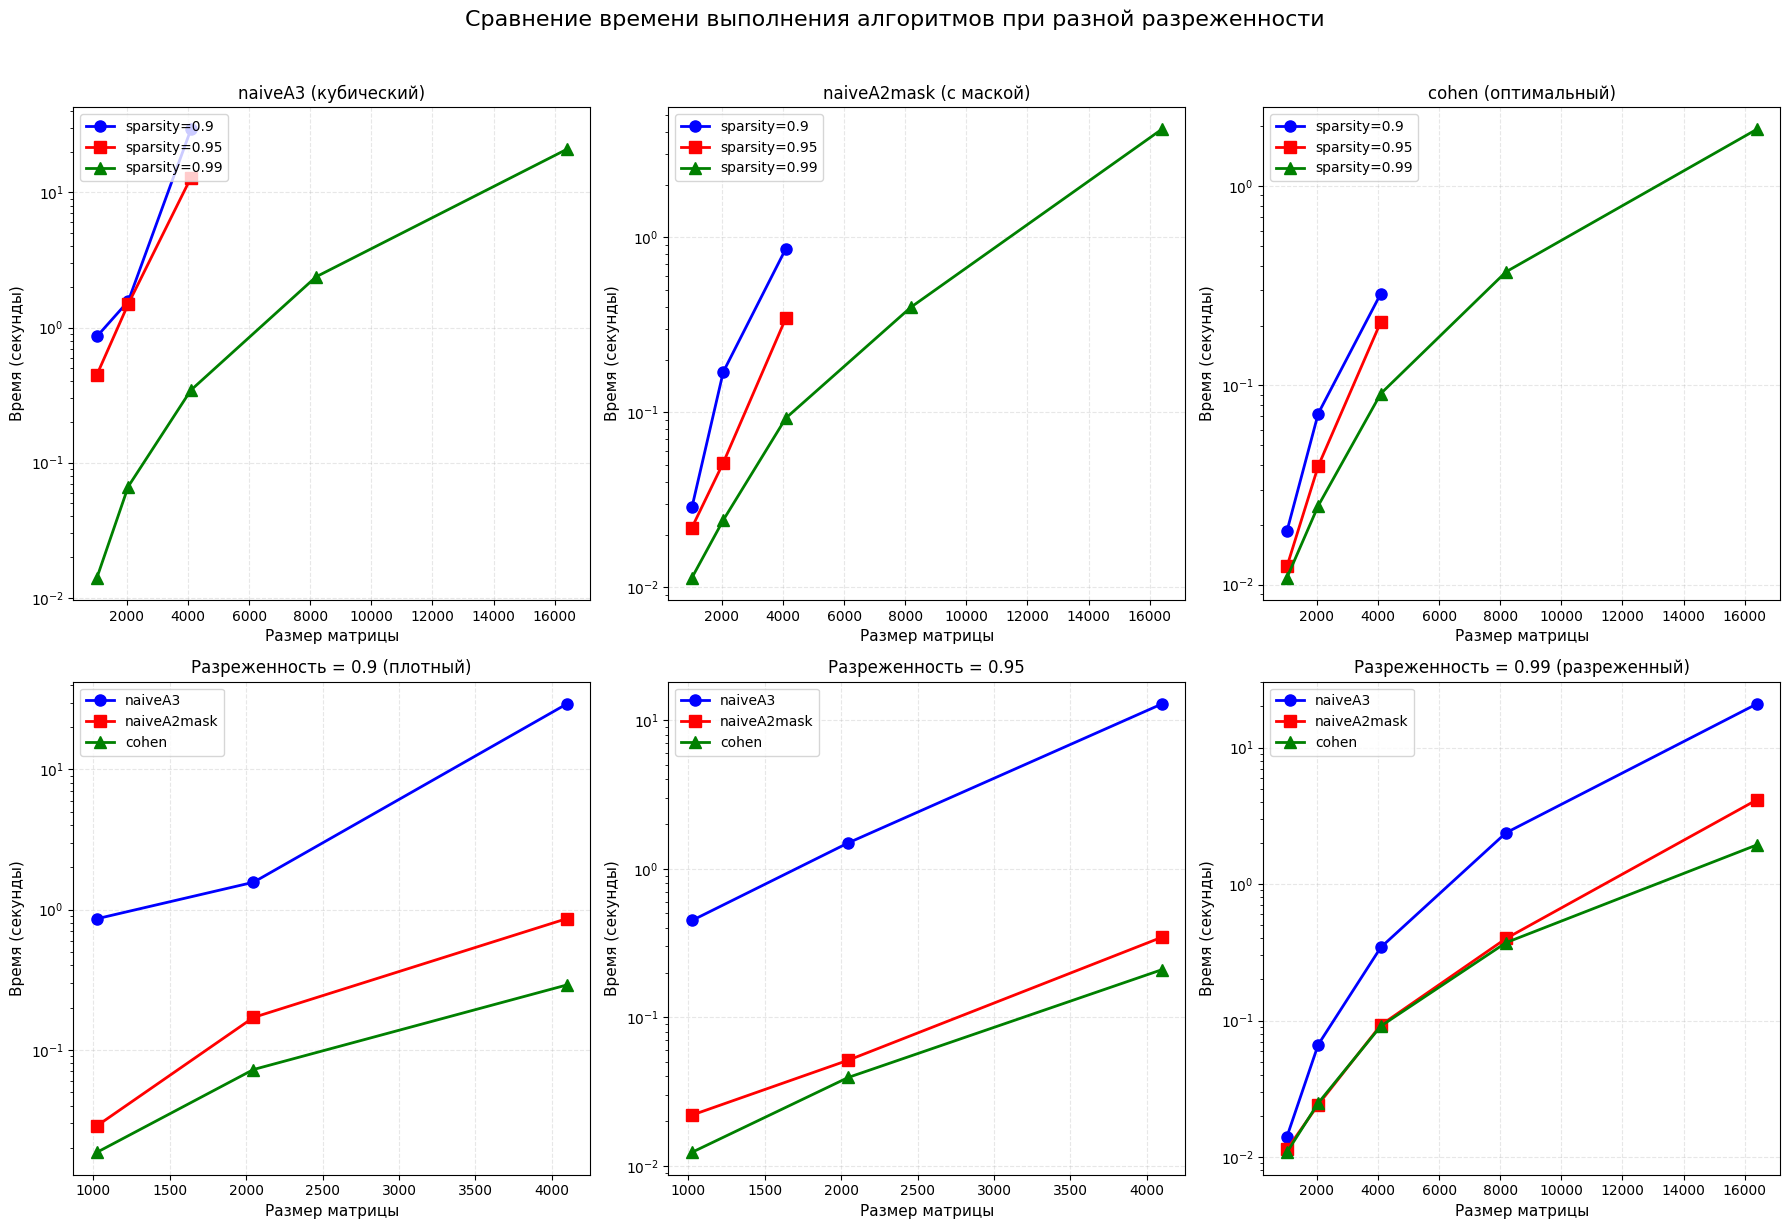

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (18, 12))
fig.suptitle('Сравнение времени выполнения алгоритмов при разной разреженности', fontsize = 16, y = 1.02)

sparsity_config = {
    0.9: {'color': 'blue', 'marker': 'o', 'label': 'sparsity = 0.9'},
    0.95: {'color': 'red', 'marker': 's', 'label': 'sparsity = 0.95'},
    0.99: {'color': 'green', 'marker': '^', 'label': 'sparsity = 0.99'}
}

algorithms = ['naiveA3', 'naiveA2mask', 'cohen']
titles_row1 = ['naiveA3 (кубический)', 'naiveA2mask (с маской)', 'cohen (оптимальный)']

for col, (algo, title) in enumerate(zip(algorithms, titles_row1)):
    ax = axes[0, col]
    
    for sparsity, config in sparsity_config.items():
        # Фильтруем данные
        data = df[(df['sparsity'] == sparsity) & (df['algorithm'] == algo)]
        
        if not data.empty:
            ax.plot(data['size'], data['time'], 
                   marker = config['marker'], 
                   color = config['color'], 
                   linewidth = 2, 
                   markersize = 8, 
                   label = config['label'])
    
    ax.grid(True, alpha = 0.3, linestyle='--')
    ax.set_xlabel('Размер матрицы', fontsize = 11)
    ax.set_ylabel('Время (секунды)', fontsize = 11)
    ax.set_title(title, fontsize = 12)
    ax.legend(loc='upper left')
    ax.set_yscale('log')

sparsities = [0.9, 0.95, 0.99]
titles_row2 = ['Разреженность = 0.9 (плотный)', 'Разреженность = 0.95', 'Разреженность = 0.99 (разреженный)']

algo_config = {
    'naiveA3': {'color': 'blue', 'marker': 'o', 'label': 'naiveA3'},
    'naiveA2mask': {'color': 'red', 'marker': 's', 'label': 'naiveA2mask'},
    'cohen': {'color': 'green', 'marker': '^', 'label': 'cohen'}
}

for col, (sparsity, title) in enumerate(zip(sparsities, titles_row2)):
    ax = axes[1, col]
    
    for algo, config in algo_config.items():
        
        data = df[(df['sparsity'] == sparsity) & (df['algorithm'] == algo)]
        
        if not data.empty:
            ax.plot(data['size'], data['time'], 
                   marker = config['marker'], 
                   color = config['color'], 
                   linewidth = 2, 
                   markersize = 8, 
                   label = config['label'])
    
    ax.grid(True, alpha = 0.3, linestyle = '--')
    ax.set_xlabel('Размер матрицы', fontsize = 11)
    ax.set_ylabel('Время (секунды)', fontsize = 11)
    ax.set_title(title, fontsize = 12)
    ax.legend(loc='upper left')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Выводы ToDo

1. **Cohen** - лучший алгоритм во всех тестах (до 58x быстрее naiveA3)

2. **naiveA3** - работает только для малых размеров ($\le 1024$) или очень разреженных графов

3. Влияние разреженности:
   - naiveA3: критическое (x39 при изменении sparsity)
   - naiveA2mask: умеренное (x6.5)
   - Cohen: слабое (x2.3)

4. Границы применимости:
   - naiveA3: до 4096 (только sparsity = 0.99)
   - naiveA2mask: до 8192 (только sparsity = 0.99)
   - Cohen: $\ge 16384$ (любая sparsity)

5. Масштабирование (n: 1024 $\to$ 16384):
   - naiveA3: время x2227 ($O(n^3)$)
   - naiveA2mask: время ×498
   - Cohen: время ×248 ($O(n^{1.5})$)

6. Практические рекомендации:
   - $n \le 2048$: любой алгоритм
   - 4096-8192: Cohen (naiveA2mask только для разреженных)
   - $n \ge 16384$: только Cohen